In [1]:
import s3fs
import polars as pl

fs = s3fs.S3FileSystem(
    endpoint_url="https://minio.lab.sspcloud.fr",
    client_kwargs={"region_name": "us-east-1"},
)

In [2]:
with fs.open("s3://projet-ape/data/08112022_27102024/naf2025/split/df_train.parquet", "rb") as f:
    df = pl.read_parquet(f)

    df = df.rename(mapping={"nace2025": "code", "libelle": "label"})[["code", "label"]]
    df = df.with_columns(
        (pl.col("code").str.slice(0, 2) + "." + pl.col("code").str.slice(2)).alias("code")
    )

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_224397/1896350165.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(code_prop["rang"], code_prop["log10_proportion"], label="$\mathcal{X}_{train\_real}$ ($\log10$)", color="#1f77b4", lw=2)
/tmp/ipykernel_224397/1896350165.py:56: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)
/tmp/ipykernel_224397/1896350165.py:61: SyntaxWarning: invalid escape sequence '\l'
  texte_equation = f"Body equation :\n$\log(Y) = {pente:.4f} \cdot X + {intercept:.2f}$"
/tmp/ipykernel_224397/1896350165.py:61: SyntaxWarning

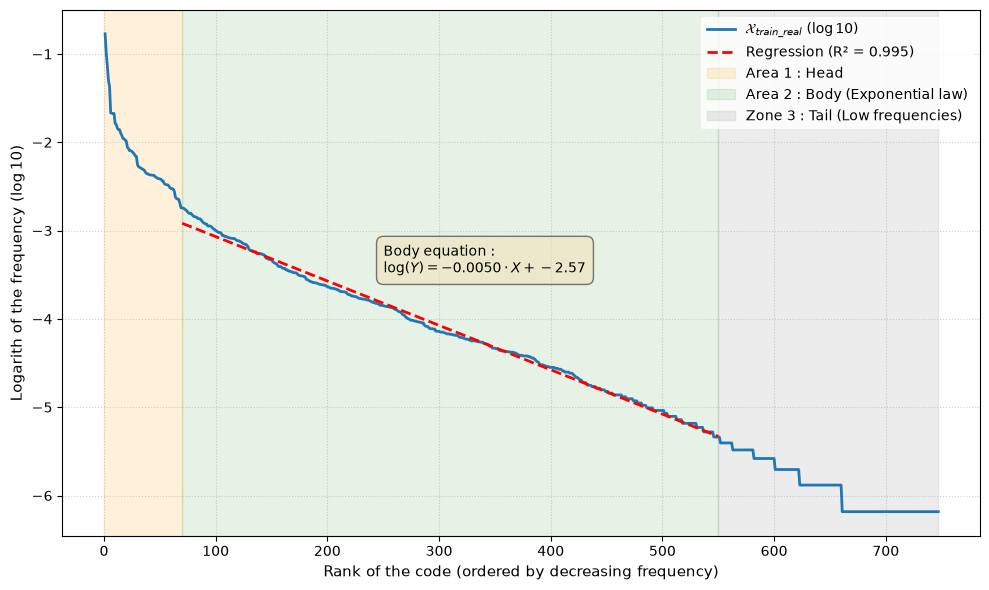

In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. PREPROCESSING
# ==========================================

code_prop = df["code"].value_counts(normalize=True).sort(by="proportion", descending=True)
code_prop = code_prop.with_columns(pl.col("proportion").log10().alias("log10_proportion"))
rangs = np.arange(1,748)
code_prop = code_prop.with_columns(pl.Series("rang", values=rangs))

# ==========================================
# 2. DÉFINITION DES ZONES & RÉGRESSION
# ==========================================
# Ajustez ces indices selon votre courbe exacte
INDEX_DEBUT_CORPS = 70
INDEX_FIN_CORPS = 550

# Filtrage de la zone centrale pour le FIT
code_prop_reg = code_prop.filter((pl.col("rang") >= INDEX_DEBUT_CORPS) & (pl.col("rang") <= INDEX_FIN_CORPS))

X = code_prop_reg.select("rang").to_numpy()
y = code_prop_reg.select("log10_proportion").to_numpy()

# Ajustement du modèle
modele = LinearRegression()
modele.fit(X, y)

# Prédiction sur la zone du corps pour affichage
y_pred = modele.predict(X)
pente = modele.coef_[0][0]
intercept = modele.intercept_[0]
r_deux = modele.score(X, y)

# ==========================================
# 3. VISUALISATION GRAPHIQUE
# ==========================================
plt.figure(figsize=(10, 6), dpi=100)

# Tracé de la courbe globale
plt.plot(code_prop["rang"], code_prop["log10_proportion"], label="$\mathcal{X}_{train\_real}$ ($\log10$)", color="#1f77b4", lw=2)

# Tracé de la droite de régression sur la zone du corps
plt.plot(X, y_pred, label=f"Regression (R² = {r_deux:.3f})", color="red", linestyle="--", lw=2)

# Coloration des zones pour la présentation
plt.axvspan(0, INDEX_DEBUT_CORPS, color="orange", alpha=0.15, label="Area 1 : Head")
plt.axvspan(INDEX_DEBUT_CORPS, INDEX_FIN_CORPS, color="green", alpha=0.1, label="Area 2 : Body (Exponential law)")
plt.axvspan(INDEX_FIN_CORPS, code_prop["rang"].max(), color="gray", alpha=0.15, label="Zone 3 : Tail (Low frequencies)")

# Habillage du graphique
plt.xlabel("Rank of the code (ordered by decreasing frequency)", fontsize=11)
plt.ylabel("Logarith of the frequency ($\log10$)", fontsize=11)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.6)

# Affichage de l'équation dans un coin du graphique
texte_equation = f"Body equation :\n$\log(Y) = {pente:.4f} \cdot X + {intercept:.2f}$"
plt.text(0.35, 0.5, texte_equation, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

In [4]:
code_count = df["code"].value_counts(normalize=False).sort(by="count", descending=True)
len(code_count.filter(pl.col("count") <= 50))

360

In [5]:
code_count.select(pl.median("count"))

count
f64
59.0


In [8]:
df["label"].is_duplicated().sum()/df["label"].count()

0.6803641906742609

In [9]:
synth_path = "s3://projet-ape/synthetic_data_test/naive/NAF2025_FR/2026-03-16_google-gemma-3-27b-it_temp14_fewshot6_exhaustive.parquet"

with fs.open(synth_path, "rb") as f:
    df_synth = pl.read_parquet(f)

In [15]:
synth_code_count = df_synth["code"].value_counts().sort(by="count", descending=True)

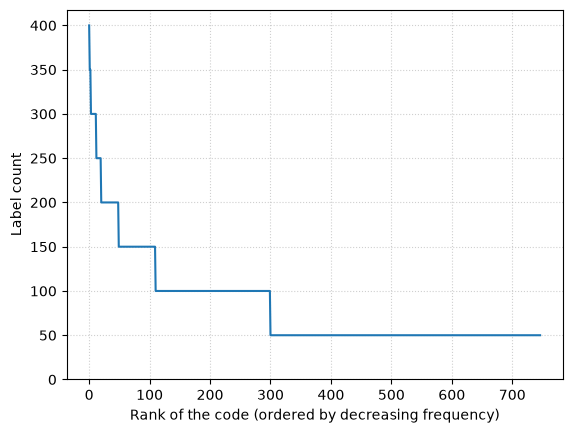

In [31]:
plt.plot(range(747), synth_code_count["count"])
plt.yticks(range(0, 450, 50))
plt.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Rank of the code (ordered by decreasing frequency)")
plt.ylabel("Label count")
plt.show()